In [1]:
import matplotlib
#import seaborn as sns
#sns.set_context("paper")
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
plt.style.use('seaborn-v0_8-colorblind')
#matplotlib.rc("font", family="Times New Roman")
# Global font settings
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 12,            # Base font size
    "axes.titlesize": 18,      # Title
    "axes.labelsize": 12,       # X and Y labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 9,
})

In [2]:
df = pd.read_csv("table_and_figure/csv/L.csv")
print(df.head())
# Define 4 base colors (one for each pair)
base_colors = ['#1f77b4',  '#ff7f0e','#2ca02c', '#d62728']  # Blue, Orange,Green, Red
# Lighter variants for the '-IR' versions
light_colors = ['#aec7e8', '#ffbb78','#98df8a',  '#f28e8c']

     SGD-IR  SGD-DA-IR  SGD-L2-DA-IR  SGD-L2-IR       SGD  SGD-L2-DA  \
0  4.273373   4.329913      4.287643   4.348234  3.964293   4.005272   
1  4.038725   4.059096      4.132384   4.063686  3.462687   3.866385   
2  3.754168   3.860333      3.974198   3.811109  3.062879   3.239804   
3  3.624002   3.778440      3.785143   3.726924  2.867400   2.931599   
4  3.389512   3.527071      3.712899   3.425166  2.763396   2.655742   

     SGD-L2    SGD-DA  
0  3.750720  4.075387  
1  3.520386  3.642658  
2  3.071596  3.473703  
3  2.594511  3.221385  
4  2.435436  2.888353  


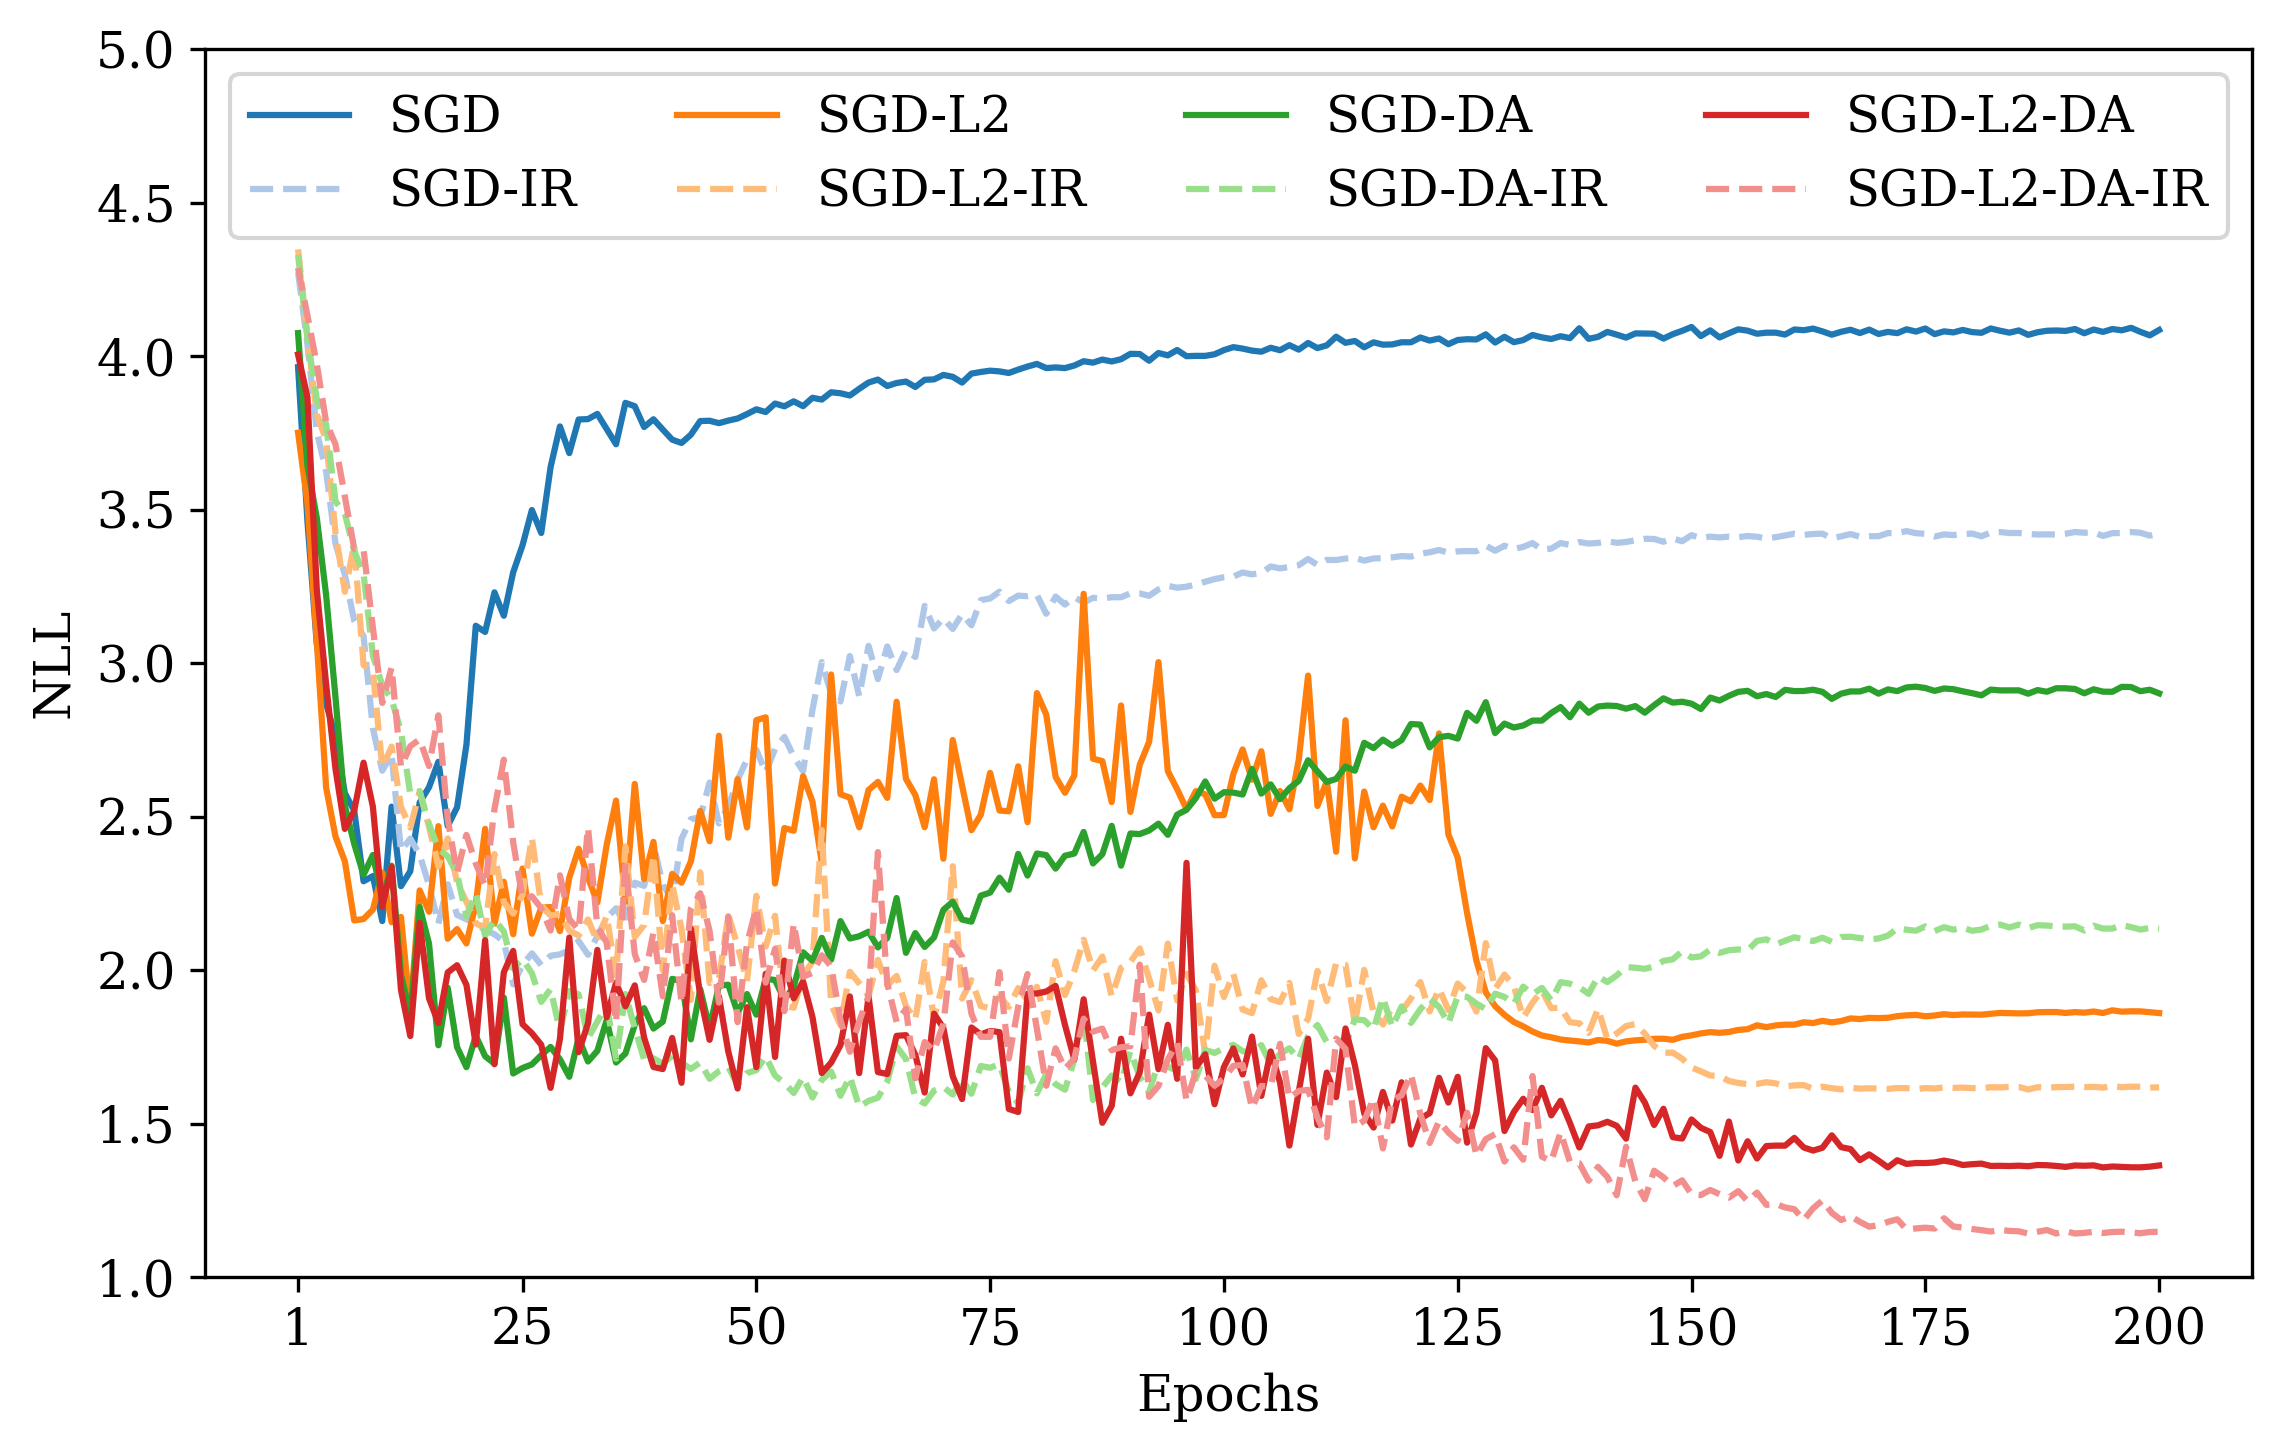

In [4]:
columns = ['SGD','SGD-L2','SGD-DA','SGD-L2-DA']

fig, ax = plt.subplots(dpi=300,figsize=(8, 5), tight_layout=True)
for indx, column in enumerate(columns):
    ax.plot(df.index + 1, df[column], label=column,color=base_colors[indx])
    column_pair = column + '-IR'
    ax.plot(df.index + 1, df[column_pair], label=column_pair,color=light_colors[indx],linestyle='--')
    xticks = list(range(0, 200 + 1, 25))
    xticks[0] = 1
    ax.set_xticks(xticks)

    ax.tick_params(axis='x', labelrotation = 0)
    ax.set(xlabel='Epochs', ylabel='NLL')
    ax.legend(loc='upper left', ncol=4, fontsize=11.95)
    #ax.set_title('ticks')
    ax.set_ylim(1.0, 5.0)
fig.show()

In [5]:
fig.savefig('ablation_nll.pdf',bbox_inches='tight',dpi=600)

### following code is the repeat for the above to plot alphaD, only difference is adjust the postion of legend according to the plot visually

     SGD-IR  SGD-DA-IR  SGD-L2-DA-IR  SGD-L2-IR       SGD  SGD-L2-DA  \
0  0.372157   0.385438      0.331649   0.276440  0.555806   0.541678   
1  0.431292   0.422431      0.484716   0.410971  0.666113   0.732493   
2  0.519617   0.498755      0.519866   0.509202  0.718941   0.707666   
3  0.545816   0.547692      0.522297   0.489499  0.764293   0.781191   
4  0.615911   0.576076      0.583802   0.576893  0.861291   0.808454   

     SGD-L2    SGD-DA  
0  0.548970  0.505384  
1  0.678832  0.581091  
2  0.729869  0.686002  
3  0.745587  0.778631  
4  0.754007  0.796622  


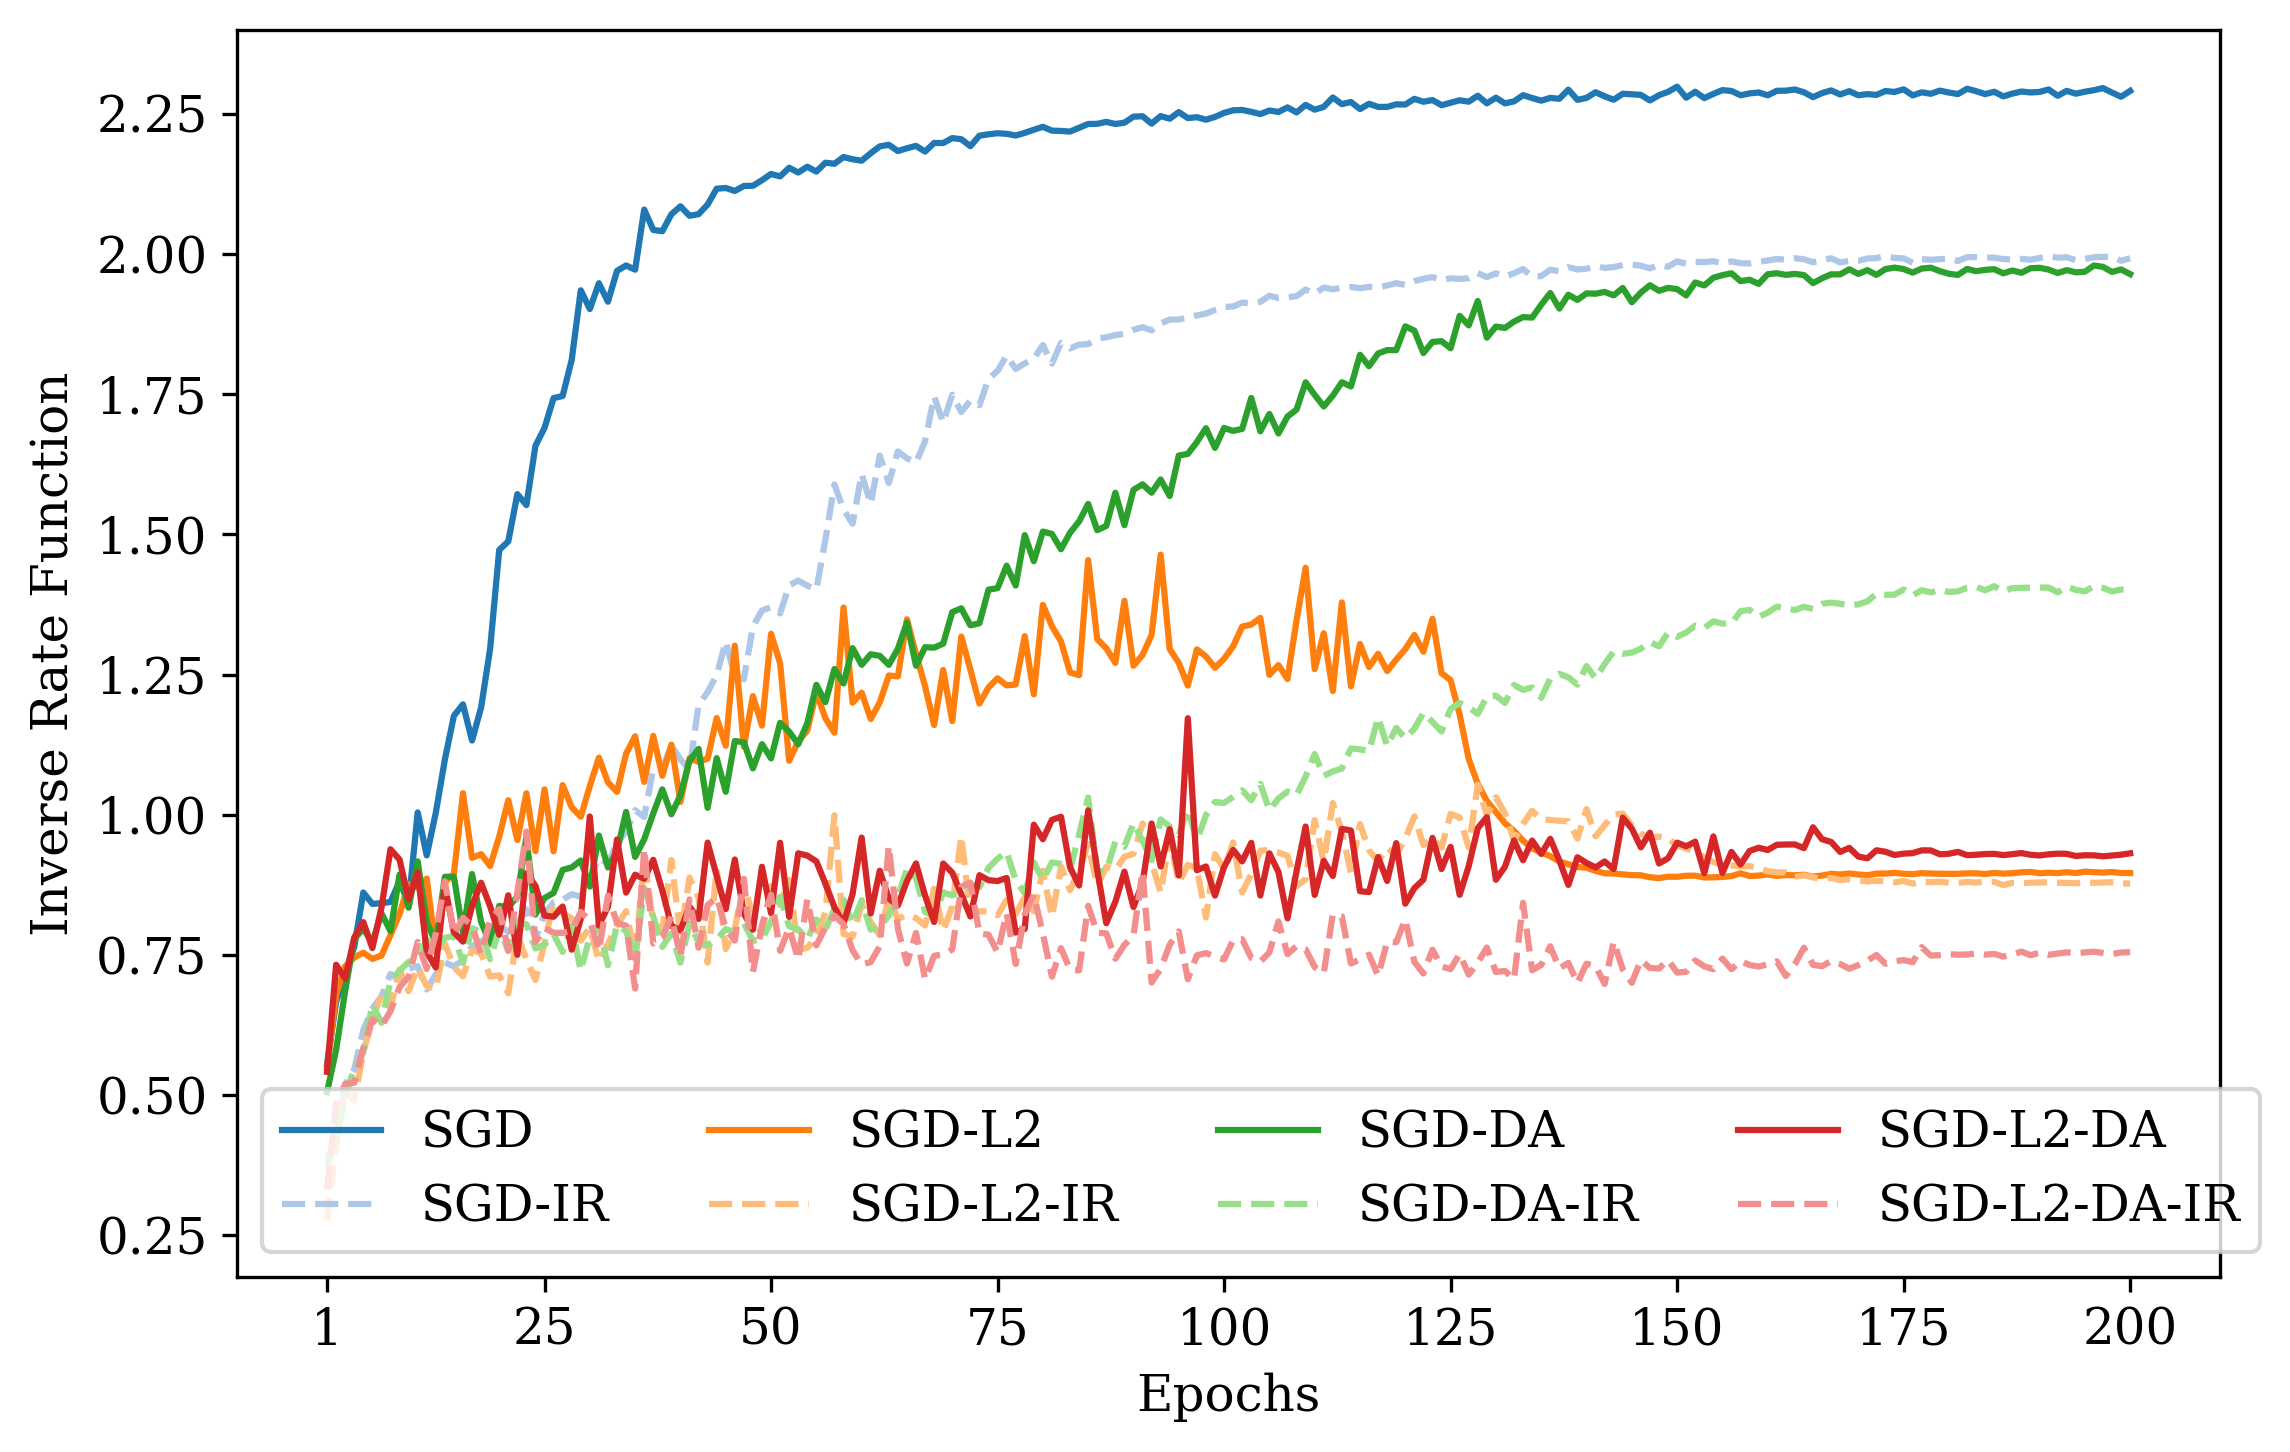

In [6]:
df = pd.read_csv("table_and_figure/csv/alphaD.csv")
print(df.head())
# Define 4 base colors for without reg
base_colors = ['#1f77b4',  '#ff7f0e','#2ca02c', '#d62728']  # Blue, Orange,Green, Red
# Lighter variants for the '-IR' versions
light_colors = ['#aec7e8', '#ffbb78','#98df8a',  '#f28e8c']
columns = ['SGD','SGD-L2','SGD-DA','SGD-L2-DA']
fig, ax = plt.subplots(dpi=300,figsize=(8, 5), tight_layout=True)
for indx, column in enumerate(columns):
    ax.plot(df.index + 1, df[column], label=column,color=base_colors[indx])
    column_pair = column + '-IR'
    ax.plot(df.index + 1, df[column_pair], label=column_pair,color=light_colors[indx],linestyle='--')
    xticks = list(range(0, 200 + 1, 25))
    xticks[0] = 1
    ax.set_xticks(xticks)
    ax.tick_params(axis='x', labelrotation = 0)
    ax.set(xlabel='Epochs', ylabel='Inverse Rate Function')
    ax.legend(
    loc='best',         # anchor point on the legend box
    #bbox_to_anchor=(0.2, 0.85), # (x, y) in axis coordinates
    #borderaxespad=0.,
    ncol=4,
    fontsize=11.95
)
    #ax.set_title('ticks')

fig.show()



In [7]:
fig.savefig('ablation_ir.pdf',bbox_inches='tight',dpi=600)